Purpose: compare cluster sizes with read counts.<br>
Author: Anna Pardo<br>
Date initiated: Nov. 19, 2025

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
plotc = pd.read_csv("./clusters_ngenes_gt_ztgroup.txt",sep="\t",header="infer")
plotc.head()

,cluster,genotype,n_CAM_genes,n_all_genes,gtc,ZTpeak
0,1,53,0,319,53_1,5.0
1,2,53,1,656,53_2,21.0
2,3,53,1,882,53_3,17.0
3,4,53,0,1071,53_4,9.0
4,5,53,0,428,53_5,21.0


In [3]:
# load total read information
cdall = pd.read_csv("../counts/coldata_deseq_heb_gtsg.txt",sep="\t",header="infer")
cdall.head()

,sample_name,genotype,treat,ZT,Total_Reads,subgenome,genotype_subgenome
0,Y1a,18,W,1,12458673,aloifolia,18_aloifolia
1,Y10a,2AB,W,3,2479905,aloifolia,2AB_aloifolia
2,Y100a,2AB,W,23,6344543,aloifolia,2AB_aloifolia
3,Y101a,2AB,D,1,8914664,aloifolia,2AB_aloifolia
4,Y103a,2AB,D,1,8074213,aloifolia,2AB_aloifolia


In [4]:
# only need one subgenome of cdall
cda = cdall[cdall["subgenome"]=="aloifolia"]

In [5]:
cda = cda[["sample_name","genotype","Total_Reads"]]

In [6]:
cda.head()

,sample_name,genotype,Total_Reads
0,Y1a,18,12458673
1,Y10a,2AB,2479905
2,Y100a,2AB,6344543
3,Y101a,2AB,8914664
4,Y103a,2AB,8074213


In [11]:
# find mean total reads across genotypes
trmeans = cda.groupby("genotype").mean().reset_index().rename(columns={"Total_Reads":"totalreads_mean"})

In [12]:
# do the same with median
trmeds = cda.groupby("genotype").median().reset_index().rename(columns={"Total_Reads":"totalreads_median"})
trmeds.head()

,genotype,totalreads_median
0,13,7992089.5
1,15,12136226.0
2,18,5961077.0
3,19,7169632.0
4,1AB,5509709.5


In [13]:
# merge
trsum = trmeds.merge(trmeans)
trsum.head()

,genotype,totalreads_median,totalreads_mean
0,13,7992089.5,9.208686e+06
1,15,12136226.0,1.282943e+07
2,18,5961077.0,8.676615e+06
3,19,7169632.0,2.274453e+07
4,1AB,5509709.5,6.598226e+06


In [14]:
plotc.head()

,cluster,genotype,n_CAM_genes,n_all_genes,gtc,ZTpeak
0,1,53,0,319,53_1,5.0
1,2,53,1,656,53_2,21.0
2,3,53,1,882,53_3,17.0
3,4,53,0,1071,53_4,9.0
4,5,53,0,428,53_5,21.0


In [17]:
# get the total number of time-structured genes in each genotype
ctotals = plotc.groupby("genotype").sum().reset_index()[["genotype","n_all_genes"]]

In [18]:
ctotals.head()

,genotype,n_all_genes
0,13,3890
1,18,24126
2,19,11028
3,1AB,19265
4,2AB,32455


In [19]:
# merge with summary stats of total reads
ctotals = ctotals.merge(trsum)
ctotals.head()

,genotype,n_all_genes,totalreads_median,totalreads_mean
0,13,3890,7992089.5,9.208686e+06
1,18,24126,5961077.0,8.676615e+06
2,19,11028,7169632.0,2.274453e+07
3,1AB,19265,5509709.5,6.598226e+06
4,2AB,32455,4789830.0,6.010655e+06


In [21]:
len(ctotals["genotype"].unique())

17

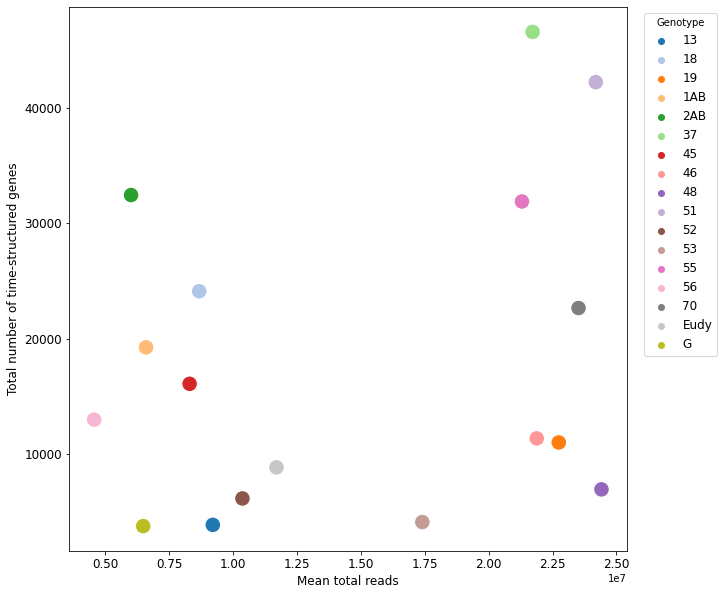

In [37]:
fig,ax = plt.subplots(figsize=(10,10))
sns.scatterplot(data=ctotals,x="totalreads_mean",y="n_all_genes",hue="genotype",palette="tab20",s=250)
plt.legend(bbox_to_anchor=(1.02,1),title="Genotype",fontsize=12)
plt.tick_params(axis="both",which="major",labelsize=12)
ax.set_xlabel("Mean total reads",fontsize=12)
ax.set_ylabel("Total number of time-structured genes",fontsize=12)
plt.savefig("./tsgenes_by_meantotalreads_pergenotype.png",dpi=200,bbox_inches="tight")
plt.savefig("./tsgenes_by_meantotalreads_pergenotype.pdf",dpi=200,bbox_inches="tight")
plt.savefig("./tsgenes_by_meantotalreads_pergenotype.svg",dpi=200,bbox_inches="tight")

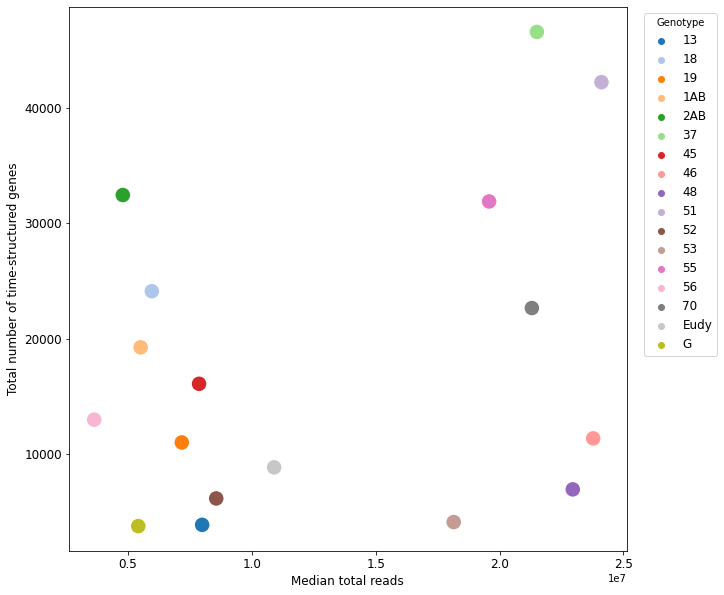

In [38]:
fig,ax = plt.subplots(figsize=(10,10))
sns.scatterplot(data=ctotals,x="totalreads_median",y="n_all_genes",hue="genotype",palette="tab20",s=250)
plt.legend(bbox_to_anchor=(1.02,1),title="Genotype",fontsize=12)
plt.tick_params(axis="both",which="major",labelsize=12)
ax.set_xlabel("Median total reads",fontsize=12)
ax.set_ylabel("Total number of time-structured genes",fontsize=12)
plt.savefig("./tsgenes_by_mediantotalreads_pergenotype.png",dpi=200,bbox_inches="tight")
plt.savefig("./tsgenes_by_mediantotalreads_pergenotype.pdf",dpi=200,bbox_inches="tight")
plt.savefig("./tsgenes_by_mediantotalreads_pergenotype.svg",dpi=200,bbox_inches="tight")

In [39]:
# quick Pearson correlation
ctotals.corr("pearson")

,n_all_genes,totalreads_median,totalreads_mean
n_all_genes,1.000000,0.334593,0.290562
totalreads_median,0.334593,1.000000,0.883780
totalreads_mean,0.290562,0.883780,1.000000


In [40]:
# function for getting p-values: from 
## https://stackoverflow.com/questions/25571882/pandas-columns-correlation-with-statistical-significance
from scipy.stats import pearsonr

def calculate_pvalues(df):
    dfcols = pd.DataFrame(columns=df.columns)
    pvalues = dfcols.transpose().join(dfcols, how='outer')
    for r in df.columns:
        for c in df.columns:
            tmp = df[df[r].notnull() & df[c].notnull()]
            pvalues[r][c] = round(pearsonr(tmp[r], tmp[c])[1], 4)
    return pvalues

In [42]:
ctotals.head()

,genotype,n_all_genes,totalreads_median,totalreads_mean
0,13,3890,7992089.5,9.208686e+06
1,18,24126,5961077.0,8.676615e+06
2,19,11028,7169632.0,2.274453e+07
3,1AB,19265,5509709.5,6.598226e+06
4,2AB,32455,4789830.0,6.010655e+06


In [44]:
calculate_pvalues(ctotals[["n_all_genes","totalreads_median","totalreads_mean"]])

,n_all_genes,totalreads_median,totalreads_mean
n_all_genes,0.0,0.1893,0.2579
totalreads_median,0.1893,0.0,0.0
totalreads_mean,0.2579,0.0,0.0
